# **Section 1: Project Overview**

## Project Overview

Tokenization is one of the most fundamental steps in Natural Language Processing (NLP). Modern language models such as GPT, BERT, LLaMA, and Gemma cannot directly process raw text. Instead, text must first be converted into a sequence of tokens, which are then mapped to numerical representations before being fed into neural networks.

A tokenizer serves as the bridge between human language and machine learning models. The quality of tokenization directly influences vocabulary coverage, sequence length, memory usage, and overall model performance.

Traditional word-level tokenization often struggles with rare or unseen words, while character-level tokenization can produce excessively long sequences. Byte Pair Encoding (BPE) was introduced as a subword tokenization technique that balances these trade-offs by learning frequently occurring character patterns and merging them into meaningful subword units.

In this project, we build a custom BPE tokenizer from scratch using the WikiText-2 dataset. The tokenizer is trained on a cleaned and deduplicated corpus and evaluated using several metrics including vocabulary size, average tokens per sentence, compression ratio, and tokenization consistency.

## Objectives

- Load and explore the WikiText-2 dataset
- Clean and preprocess the training corpus
- Remove duplicate text samples
- Train a custom BPE tokenizer
- Analyze the learned vocabulary
- Evaluate tokenizer performance
- Save and reload the tokenizer in Hugging Face compatible format
- Demonstrate practical encoding and decoding workflows


---

# **Section 2: Understanding Tokenization**

## Understanding Tokenization

Large Language Models operate on numerical inputs rather than raw text. Before text can be processed by a model, it must be converted into smaller units called tokens.

The overall NLP pipeline can be summarized as:

Raw Text
→ Tokenization
→ Token IDs
→ Embeddings
→ Neural Network

**For example:**

Input Text:
"Machine learning is fascinating."

Possible Tokens:
```
["Machine", "learning", "is", "fascinating", "."]
```

Token IDs:
```
[1352, 7821, 54, 9317, 13]
```

The choice of tokenization strategy significantly impacts:

- Vocabulary size
- Memory requirements
- Sequence length
- Ability to handle unseen words
- Training efficiency

Over the years, three major tokenization approaches have emerged:
1. Word-level tokenization
2. Character-level tokenization
3. Subword tokenization (BPE, WordPiece, SentencePiece)

Modern language models predominantly rely on subword tokenization techniques because they offer an effective balance between vocabulary size and language coverage.

---

# **Section 3: Why BPE?**

## Limitations of Word-Level Tokenization

Word-level tokenizers treat each word as a unique vocabulary item.

Example:

Vocabulary:
```
["machine", "learning", "artificial", "intelligence"]
```

Input:
"electromechanical"

Result:
[UNK]

Any unseen word becomes an unknown token, resulting in information loss.

---

## Limitations of Character-Level Tokenization

Character tokenization solves the unknown word problem by treating every character as a token.

Example:

"electromechanical"

↓
```
["e", "l", "e", "c", "t", "r", "o", ...]
```

While this approach eliminates unknown words, it creates extremely long sequences that increase computational cost.

---

## BPE: A Middle Ground

Byte Pair Encoding begins with individual characters and repeatedly merges frequently occurring character pairs.

Example:

electromechanical

↓

electro + mechanical

Instead of storing every possible word, BPE learns reusable subword units that can represent both common and rare words.

Advantages:

- Handles unseen words effectively
- Produces shorter sequences than character tokenization
- Requires a smaller vocabulary than word-level tokenization
- Widely used in modern transformer architectures

---

# **Section 4: Dataset Loading**

## Dataset Description

To train our tokenizer, we use the WikiText-2 dataset available through Hugging Face.

WikiText-2 is a benchmark dataset derived from high-quality Wikipedia articles and is widely used for language modeling research.

Why WikiText-2?

- Clean and well-structured English text
- Diverse vocabulary
- Suitable size for experimentation
- Commonly used in NLP benchmarking

The dataset contains three splits:

- Training Set
- Validation Set
- Test Set

As with machine learning workflows, tokenizer training will only use the training split to avoid information leakage from evaluation datasets.

## **4.1: Load Dataset**

In [1]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-v1"
)

dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:122: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-v1/test-00000-of-00001.parque(…):   0%|          | 0.00/685k [00:00<?, ?B/s]

wikitext-2-v1/train-00000-of-00001.parqu(…):   0%|          | 0.00/6.07M [00:00<?, ?B/s]

wikitext-2-v1/validation-00000-of-00001.(…):   0%|          | 0.00/618k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})

## **4.2: Dataset Exploration**

In [2]:
for split in dataset:
    print(f"\n{split.upper()}")
    print(dataset[split])


TEST
Dataset({
    features: ['text'],
    num_rows: 4358
})

TRAIN
Dataset({
    features: ['text'],
    num_rows: 36718
})

VALIDATION
Dataset({
    features: ['text'],
    num_rows: 3760
})


In [3]:
train_df = dataset["train"].to_pandas()
valid_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train Shape:", train_df.shape)
print("Validation Shape:", valid_df.shape)
print("Test Shape:", test_df.shape)

Train Shape: (36718, 1)
Validation Shape: (3760, 1)
Test Shape: (4358, 1)


In [4]:
train_df.head(10)

,text
0,
1,= Valkyria Chronicles III = \n
2,
3,Senjō no Valkyria 3 : <unk> Chronicles ( Japa...
4,"The game began development in 2010 , carrying..."
5,"It met with positive sales in Japan , and was..."
6,
7,= = Gameplay = = \n
8,
9,"As with previous <unk> Chronicles games , Val..."


In [11]:
train_df["text"][3]

' Senjō no Valkyria 3 : <unk> Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . <unk> the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs parallel to the first game and follows the " Nameless " , a penal military unit serving the nation of Gallia during the Second Europan War who perform secret black operations and are pitted against the Imperial unit " <unk> Raven " . \n'

## Observations

The WikiText-2 corpus contains occurrences of the token `<unk>`,
which represents words that were unknown during a previous
preprocessing stage.

Since our goal is to train a tokenizer from scratch on natural
language text, these placeholder tokens do not contribute useful
linguistic information and are therefore removed before training.

# **Section 5: Dataset Cleaning**

# Data Cleaning and Preprocessing

Raw text corpora often contain artifacts that can negatively affect
tokenizer training.

Before training our BPE tokenizer, we perform several preprocessing
steps to improve corpus quality:

1. Remove empty rows
2. Remove whitespace-only rows
3. Remove placeholder `<unk>` tokens
4. Remove exact duplicate entries

These steps help ensure that vocabulary statistics are derived from
meaningful linguistic content rather than noise or repeated records.

## **5.1 Initial Statistics**

In [12]:
print("Original Rows:", len(train_df))

empty_rows = train_df["text"].str.strip().eq("").sum()

print("Empty Rows:", empty_rows)

Original Rows: 36718
Empty Rows: 12951


## **5.2 Remove Empty Rows**

In [13]:
train_clean = train_df.copy()

train_clean = train_clean[
    train_clean["text"].str.strip() != ""
]

print("Rows After Empty Removal:", len(train_clean))

Rows After Empty Removal: 23767


## **5.3 Remove < unk >**

In [14]:
train_clean["text"] = (
    train_clean["text"]
    .str.replace("<unk>", "", regex=False)
)

## **5.4 Deduplicate**

In [15]:
before = len(train_clean)

train_clean = train_clean.drop_duplicates()

after = len(train_clean)

print("Duplicates Removed:", before - after)
print("Final Rows:", after)

Duplicates Removed: 2430
Final Rows: 21337


## **5.5 Build Training Corpus**

In [26]:
corpus = train_clean["text"].tolist()

print("Documents for Training:", len(corpus))

Documents for Training: 21337


In [27]:
train_clean["text"] = (
    train_clean["text"]
    .str.replace("<unk>", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

---

After removing `<unk>` placeholders, consecutive whitespace characters were normalized to a single space. This prevents artifacts such as "(  )" from appearing in the training corpus while preserving the original linguistic content.

---

## Cleaning Results

The raw WikiText-2 training split contained a substantial number of empty and duplicate entries.

Cleaning Summary:

| Stage | Rows |
|---------|---------:|
| Original Training Rows | 36,718 |
| Empty Rows Removed | 12,951 |
| Rows After Empty Removal | 23,767 |
| Duplicate Rows Removed | 2,430 |
| Final Training Corpus | 21,337 |

### Key Observations

- Approximately 35% of the original rows were empty or whitespace-only entries.
- Over 2,400 duplicate records were identified and removed.
- The final corpus contains 21,337 unique text samples used for tokenizer training.

Removing empty and duplicate entries improves corpus quality and prevents vocabulary statistics from being biased by repeated content.

# **Section 6: Corpus Exploration**

## **6.1 Average Text Length**

In [28]:
train_clean["char_length"] = train_clean["text"].str.len()

train_clean["char_length"].describe()

,char_length
count,21337.000000
mean,483.275531
std,416.847604
min,0.000000
25%,52.000000
50%,448.000000
75%,746.000000
max,3768.000000


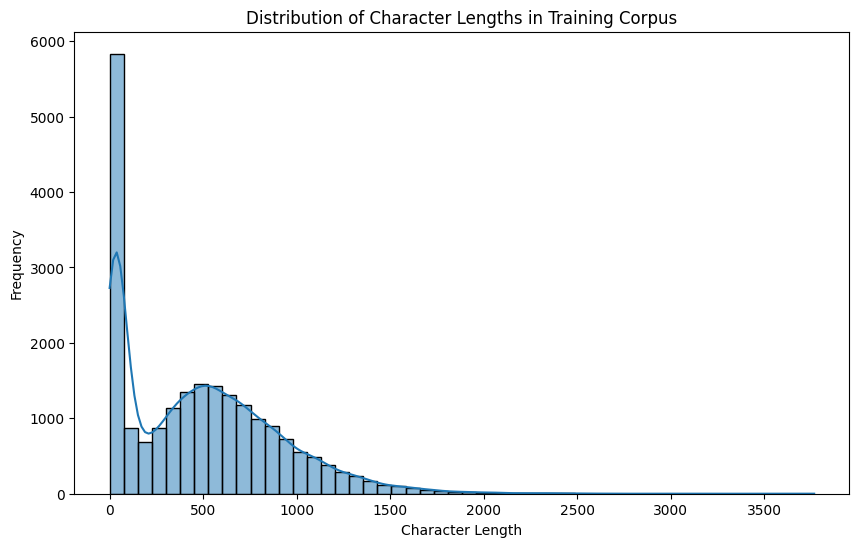

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(train_clean['char_length'], bins=50, kde=True)
plt.title('Distribution of Character Lengths in Training Corpus')
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.show()

## **6.2 Longest Samples**

In [30]:
train_clean.nlargest(
    5,
    "char_length"
)[["text","char_length"]]

,text,char_length
33054,"At the same time , a local court in Germany ru...",3768
6453,Aniston 's performance in Friends has been pra...,3572
25640,"The protagonist of the game , a young man name...",3147
1341,"to use herself as the butt of her own jokes , ...",2684
2316,"NPR 's Ken Tucker described the album as a "" g...",2642


## **6.3 Random Samples**

In [31]:
train_clean["text"].sample(
    5,
    random_state=42
).tolist()

["After returning to the United States in January 1919 , O 'Brien returned to European waters in May to serve as one of the picket ships for the NC @-@ type seaplanes in the first aerial crossing of the Atlantic . O 'Brien was decommissioned at Philadelphia in June 1922 . She was struck from the Naval Vessel Register in March 1935 sold for scrapping in April .",
 'Chemical Valley and the surrounding area are home to 62 facilities and refineries . These industrial complexes are the heart of Sarnia \'s infrastructure and economy . They directly employ nearly 8 @,@ 000 , and contribute to almost 45 @,@ 000 additional jobs in the area . In 1971 , the Canadian government deemed this area so important to the economic development of the country that it printed an image of a Sarnia Oil on the reverse of the Canadian $ 10 note . The huge industrial area is the cause of significant air and water pollution . The Canada Wide Daily Standard for airborne particulate matter and pollution , regulation

## **6.4 Unique Vocabulary Before BPE**

In [32]:
all_words = " ".join(train_clean["text"]).split()

unique_words = set(all_words)

print(f"Unique Words: {len(unique_words):,}")

Unique Words: 33,276


## Corpus Vocabulary Analysis

Before training the tokenizer, we examine the raw vocabulary contained in the cleaned corpus.

The cleaned training corpus contains:

- 21,337 unique text entries
- 33,276 unique words

At first glance, a vocabulary of 33,276 words may appear manageable. However, many of these words occur infrequently and include morphological variations, proper nouns, numbers, and domain-specific terms.

Examples:

- play
- playing
- played
- player
- players

A word-level tokenizer would treat each variation as a separate vocabulary item. In contrast, Byte Pair Encoding (BPE) learns reusable subword units that can represent these variations more efficiently.

This ability to reuse subword components is one of the primary reasons modern language models rely on BPE-style tokenization rather than pure word-level vocabularies.

---

# **Section 7: Understanding BPE Through a Simple Example**

Before training a tokenizer on the WikiText-2 corpus, it is useful to understand how Byte Pair Encoding (BPE) works at a conceptual level.

BPE begins with individual characters and repeatedly merges the most frequently occurring adjacent symbol pairs.

Consider the following toy corpus:

low
lower
newest
widest

Initially, every word is represented as a sequence of characters.

low     → l o w
lower   → l o w e r
newest  → n e w e s t
widest  → w i d e s t

The algorithm then:

1. Counts all adjacent symbol pairs
2. Finds the most frequent pair
3. Merges that pair into a new symbol
4. Repeats the process

Over many iterations, common character combinations gradually become meaningful subword units.

This allows BPE to represent rare words using reusable subword components while maintaining a manageable vocabulary size.

**Simple Demonstration**

In [33]:
toy_corpus = [
    "low",
    "lower",
    "newest",
    "widest"
]

for word in toy_corpus:
    print(" ".join(list(word)))

l o w
l o w e r
n e w e s t
w i d e s t


Suppose the pair:
```
e + s
```
appears most frequently.

After merging:
```
newest  → n e w es t

widest  → w i d es t
```

If the pair:

```
es + t
```
becomes the most frequent pair, another merge occurs:
```
newest  → n e w est
widest  → w i d est
```
Over thousands of merge operations, frequently occurring patterns such as:

- ing
- tion
- ment
- pre

emerge naturally from the training corpus.

This ability to learn reusable subword units is the key idea behind Byte Pair Encoding.

# **Section 8: Training BPE**

## **Training Configuration**

The tokenizer will be trained using Hugging Face's Tokenizers library.

Although the implementation is provided by the library, the vocabulary itself is learned entirely from the WikiText-2 corpus.

The tokenizer starts with character-level units and iteratively learns subword merges until the target vocabulary size is reached.

## Training Parameters

| Parameter | Value |
|------------|--------|
| Algorithm | Byte Pair Encoding (BPE) |
| Vocabulary Size | 30,000 |
| Training Corpus | Cleaned WikiText-2 Training Split |
| Documents | 21,337 |
| Unique Words | 33,276 |
| Special Tokens | 5 |
| Pre-tokenizer | Whitespace |

## Special Tokens

The following special tokens are included:

- [PAD]
- [UNK]
- [CLS]
- [SEP]
- [MASK]

These tokens improve compatibility with downstream NLP and language modeling tasks.

## **8.1 Why Whitespace Pre-Tokenization?**

Before applying BPE merges, text is first split into coarse word-like units using whitespace.

Example:

Machine learning is fascinating.

↓
```
["Machine", "learning", "is", "fascinating."]
```
BPE then learns subword patterns within these units.

Without pre-tokenization, merges could occur across unrelated word boundaries, resulting in less meaningful subword representations.

Whitespace pre-tokenization provides a simple and effective starting point while still allowing BPE to discover useful subword structures.

**Imports**

In [36]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer

## **8.2 Create Tokenizer**

In [37]:
tokenizer = Tokenizer(
    BPE(
        unk_token="[UNK]"
    )
)

tokenizer.pre_tokenizer = Whitespace()

## **8.3 Create Trainer**

In [38]:
trainer = BpeTrainer(
    vocab_size=30000,
    special_tokens=[
        "[PAD]",
        "[UNK]",
        "[CLS]",
        "[SEP]",
        "[MASK]"
    ]
)

## **Section 8.4: Training the Tokenizer**

The tokenizer is now trained on the cleaned WikiText-2 corpus.

During training, the BPE algorithm:

1. Starts with character-level units
2. Counts adjacent symbol pairs
3. Identifies the most frequent pair
4. Merges that pair into a new token
5. Repeats until the target vocabulary size is reached

The resulting vocabulary consists of both individual characters and frequently occurring subword units learned directly from the corpus.

Training is performed only on the cleaned training split to avoid information leakage from validation and test data.

**Training Code**

In [39]:
tokenizer.train_from_iterator(
    corpus,
    trainer=trainer
)

# **Section 9: Inspecting the Learned Vocabulary**

After training, the tokenizer has learned a vocabulary consisting of characters, words, and subword units.

Unlike a traditional word-level tokenizer, BPE learns reusable components that can represent both common and rare words efficiently.

Inspecting the learned vocabulary helps us understand which linguistic patterns were considered important by the algorithm.

## **9.1 Vocabulary Size**

In [41]:
print("Vocabulary Size:", tokenizer.get_vocab_size())

Vocabulary Size: 30000


## **9.2 Sample Vocabulary**

In [47]:
vocab = tokenizer.get_vocab()

In [52]:
sorted_vocab = sorted(
    vocab.items(),
    key=lambda x: x[1]
)

sorted_vocab[1000:1050]

[('Se', 1000),
 ('Car', 1001),
 ('They', 1002),
 ('50', 1003),
 ('km', 1004),
 ('area', 1005),
 ('design', 1006),
 ('ross', 1007),
 ('million', 1008),
 ('tri', 1009),
 ('orn', 1010),
 ('state', 1011),
 ('because', 1012),
 ('ress', 1013),
 ('mis', 1014),
 ('ather', 1015),
 ('cy', 1016),
 ('formed', 1017),
 ('each', 1018),
 ('sim', 1019),
 ('xt', 1020),
 ('plac', 1021),
 ('erson', 1022),
 ('ca', 1023),
 ('August', 1024),
 ('14', 1025),
 ('ink', 1026),
 ('jor', 1027),
 ('come', 1028),
 ('vol', 1029),
 ('rist', 1030),
 ('read', 1031),
 ('overn', 1032),
 ('fect', 1033),
 ('13', 1034),
 ('people', 1035),
 ('east', 1036),
 ('ower', 1037),
 ('Sep', 1038),
 ('chool', 1039),
 ('Ju', 1040),
 ('ock', 1041),
 ('vide', 1042),
 ('Gr', 1043),
 ('serv', 1044),
 ('car', 1045),
 ('let', 1046),
 ('support', 1047),
 ('oot', 1048),
 ('ple', 1049)]

In [55]:
sorted_vocab[15000:15050]

[('mosque', 15000),
 ('guerrilla', 15001),
 ('Bootleg', 15002),
 ('antagonist', 15003),
 ('Siege', 15004),
 ('issartensis', 15005),
 ('shooter', 15006),
 ('Thanhouser', 15007),
 ('Honduras', 15008),
 ('Kristians', 15009),
 ('Tunnel', 15010),
 ('libret', 15011),
 ('bernissartensis', 15012),
 ('epithet', 15013),
 ('mycorrhizal', 15014),
 ('ancholy', 15015),
 ('ribosom', 15016),
 ('umbria', 15017),
 ('Duchess', 15018),
 ('Oswald', 15019),
 ('wisdom', 15020),
 ('convicted', 15021),
 ('Woodsboro', 15022),
 ('Hydnellum', 15023),
 ('Vaishnava', 15024),
 ('AoT', 15025),
 ('Delta', 15026),
 ('ESPN', 15027),
 ('Gofraid', 15028),
 ('Geastrum', 15029),
 ('Kumar', 15030),
 ('Moody', 15031),
 ('Movement', 15032),
 ('Owego', 15033),
 ('Oricon', 15034),
 ('Sovets', 15035),
 ('eukary', 15036),
 ('gendarmerie', 15037),
 ('insurgents', 15038),
 ('knuckleball', 15039),
 ('ecclesiastical', 15040),
 ('317', 15041),
 ('Amede', 15042),
 ('Bile', 15043),
 ('Body', 15044),
 ('Basket', 15045),
 ('CS', 15046),
 (

In [56]:
sorted_vocab[25000:25050]

[('longitudinal', 25000),
 ('paragraph', 25001),
 ('ostensibly', 25002),
 ('Seydlitz', 25003),
 ('atherfieldensis', 25004),
 ('promyelocytic', 25005),
 ('Guadalupe', 25006),
 ('McPherson', 25007),
 ('McDonough', 25008),
 ('cirrhifer', 25009),
 ('Strategic', 25010),
 ('potassium', 25011),
 ('Freewheelin', 25012),
 ('Ferguson', 25013),
 ('Muhammadiyah', 25014),
 ('Habroptila', 25015),
 ('sarcophagus', 25016),
 ('050', 25017),
 ('216', 25018),
 ('225', 25019),
 ('228', 25020),
 ('311', 25021),
 ('322', 25022),
 ('470', 25023),
 ('490', 25024),
 ('5000', 25025),
 ('570', 25026),
 ('56th', 25027),
 ('630', 25028),
 ('64th', 25029),
 ('68th', 25030),
 ('740', 25031),
 ('790', 25032),
 ('73rd', 25033),
 ('716th', 25034),
 ('815', 25035),
 ('880', 25036),
 ('84th', 25037),
 ('920', 25038),
 ('970', 25039),
 ('995', 25040),
 ('Aby', 25041),
 ('Asi', 25042),
 ('Ara', 25043),
 ('Ack', 25044),
 ('Ascen', 25045),
 ('Agent', 25046),
 ('Atoll', 25047),
 ('Agate', 25048),
 ('Ayl', 25049)]

## **9.3 Tokenization Test**

### Testing the Trained Tokenizer

To verify that the tokenizer functions correctly, we encode and decode a sample sentence.

The encoded representation consists of learned subword tokens and their corresponding token IDs.

Successful decoding should reconstruct the original text with minimal information loss.

**Test Sentence**

In [49]:
sample_text = "Machine learning is transforming artificial intelligence."

**Encode**

In [50]:
encoding = tokenizer.encode(sample_text)

print("Tokens:")
print(encoding.tokens)

print("\nToken IDs:")
print(encoding.ids)

Tokens:
['Machine', 'learning', 'is', 'transforming', 'artificial', 'intelligence', '.']

Token IDs:
[10300, 6760, 303, 27993, 7479, 5959, 18]


**Decode**

In [54]:
decoded = tokenizer.decode(encoding.ids)

print("Decoded Text:",decoded)

Decoded Text: Machine learning is transforming artificial intelligence .


## Vocabulary Analysis

Inspection of the learned vocabulary reveals the hierarchical nature of BPE tokenization.

Low-index tokens primarily consist of highly frequent character pairs and common English subwords:

- th
- in
- er
- ed
- the

Mid-range tokens include frequently occurring words and phrases:

- state
- million
- area
- design

Higher-index tokens increasingly contain domain-specific terminology, proper nouns, and less frequent vocabulary:

- potassium
- sarcophagus
- ecclesiastical
- Ferguson
- Muhammadiyah

This progression illustrates how BPE gradually allocates vocabulary capacity to increasingly specific linguistic patterns as training proceeds.

## **9.4 Rare and Out-of-Vocabulary Word Analysis**

In [61]:
test_words = [
    "electromechanical",
    "internationalization",
    "transformational",
    "AnalyticsVidhya",
    "Ruthuraraj",
    "ChatGPT",
    "someone@somemail.com",
    "puthagam"
]

In [62]:
for word in test_words:
    encoding = tokenizer.encode(word)

    print(f"\nWord: {word}")
    print("Tokens:", encoding.tokens)


Word: electromechanical
Tokens: ['elect', 'rome', 'chan', 'ical']

Word: internationalization
Tokens: ['international', 'ization']

Word: transformational
Tokens: ['transform', 'ational']

Word: AnalyticsVidhya
Tokens: ['Analy', 'tics', 'V', 'id', 'hy', 'a']

Word: Ruthuraraj
Tokens: ['Ru', 'thur', 'ara', 'j']

Word: ChatGPT
Tokens: ['Ch', 'at', 'GP', 'T']

Word: someone@somemail.com
Tokens: ['someone', '@', 'som', 'email', '.', 'com']

Word: puthagam
Tokens: ['p', 'uth', 'ag', 'am']


## Rare and Out-of-Vocabulary Word Analysis

One of the primary advantages of BPE tokenization is its ability to represent words that were never observed during training.

Several rare and unseen words were tested:

| Word | Learned Decomposition |
|--------|----------------------|
| electromechanical | elect + rome + chan + ical |
| internationalization | international + ization |
| transformational | transform + ational |
| AnalyticsVidhya | Analy + tics + V + id + hy + a |
| Ruthuraraj | Ru + thur + ara + j |
| ChatGPT | Ch + at + GP + T |

The results demonstrate that the tokenizer has learned reusable subword units capable of representing unseen vocabulary without relying on a generic unknown token.

This property significantly improves vocabulary coverage while maintaining a manageable vocabulary size.

# **Section 10: Tokenizer Evaluation**

Training a tokenizer is only the first step. To understand its effectiveness, we evaluate its behavior on unseen data using the validation and test splits of WikiText-2.

The following metrics are analyzed:

1. Vocabulary Size
2. Tokenization Consistency
3. Average Tokens per Sentence
4. Compression Ratio

Together, these metrics provide insight into vocabulary coverage, sequence efficiency, and the tokenizer's ability to represent text compactly.

## **Metric 1: Vocabulary Size**

In [63]:
print("Vocabulary Size:", tokenizer.get_vocab_size())

Vocabulary Size: 30000


The tokenizer successfully learned a vocabulary containing 30,000 tokens.

The vocabulary includes:

- Individual characters
- Common subwords
- Frequent words
- Domain-specific terms
- Special tokens

This vocabulary size provides a balance between language coverage and computational efficiency.

## **Metric 2: Tokenization Consistency**

In [66]:
sample_text = "Learning Byte Pair Encoding through coding was fun."

encoding1 = tokenizer.encode(sample_text)
encoding2 = tokenizer.encode(sample_text)

print(encoding1.tokens)
print(encoding2.tokens)

print(
    encoding1.tokens == encoding2.tokens
)

['Learning', 'By', 'te', 'P', 'air', 'En', 'coding', 'through', 'coding', 'was', 'fun', '.']
['Learning', 'By', 'te', 'P', 'air', 'En', 'coding', 'through', 'coding', 'was', 'fun', '.']
True


The tokenizer produced identical token sequences across repeated encoding operations.

This confirms deterministic tokenization behavior, ensuring reproducible preprocessing during model training and inference.

## **Metric 3: Average Tokens per Sentence**

**Lets use the validation split!!**

In [67]:
valid_df = dataset["validation"].to_pandas()

valid_clean = valid_df.copy()

valid_clean = valid_clean[
    valid_clean["text"].str.strip() != ""
]

valid_clean["text"] = (
    valid_clean["text"]
    .str.replace("<unk>", "", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

valid_texts = valid_clean["text"].tolist()

**Compute Average Tokens**

In [68]:
token_counts = []

for text in valid_texts:
    token_counts.append(
        len(tokenizer.encode(text).tokens)
    )

avg_tokens = sum(token_counts) / len(token_counts)

print(
    f"Average Tokens per Sentence: {avg_tokens:.2f}"
)

Average Tokens per Sentence: 84.96


## **Metric 4: Compression Ratio**

**Concept**

If:

> Original Text = 100 characters

and

> Tokenized Output = 25 tokens

then:

> Compression Ratio = 100 / 25 = 4.0

Meaning:

* Each token represents roughly
* 4 characters of information.

In [69]:
total_chars = 0
total_tokens = 0

for text in valid_texts:
    total_chars += len(text)

    total_tokens += len(
        tokenizer.encode(text).tokens
    )

compression_ratio = (
    total_chars / total_tokens
)

print(
    f"Compression Ratio: {compression_ratio:.2f}"
)

Compression Ratio: 4.97


## **Evaluation Summary Table**

In [72]:
import pandas as pd

results = pd.DataFrame({
    "Metric": [
        "Vocabulary Size",
        "Average Tokens per Sentence",
        "Compression Ratio"
    ],
    "Value": [
        tokenizer.get_vocab_size(),
        round(avg_tokens, 2),
        round(compression_ratio, 2)
    ]
})

results

,Metric,Value
0,Vocabulary Size,30000.00
1,Average Tokens per Sentence,84.96
2,Compression Ratio,4.97


# **Section 11: Visualizations**

## **Figure 1: Dataset Cleaning Summary**

The training corpus underwent several preprocessing stages before tokenizer training.

This visualization summarizes how the corpus size changed after removing empty rows and duplicate entries.

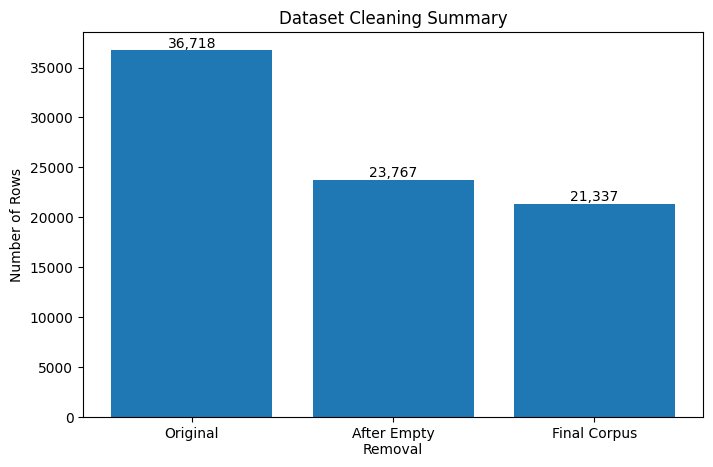

In [73]:
import matplotlib.pyplot as plt

stages = [
    "Original",
    "After Empty\nRemoval",
    "Final Corpus"
]

counts = [
    36718,
    23767,
    21337
]

plt.figure(figsize=(8,5))
plt.bar(stages, counts)

plt.title("Dataset Cleaning Summary")
plt.ylabel("Number of Rows")

for i, value in enumerate(counts):
    plt.text(i, value + 300, f"{value:,}", ha="center")

plt.savefig("data_cleaning_summary.png")

The cleaning process reduced the training corpus from 36,718 rows to 21,337 unique text samples.

The largest reduction occurred during empty-row removal, highlighting the prevalence of formatting-related entries within the WikiText-2 corpus.

## **Figure 2: Vocabulary Hierarchy Learned by BPE**

The learned vocabulary progresses from common character pairs to increasingly specialized words and named entities.

This demonstrates the hierarchical nature of BPE vocabulary construction.

In [74]:
import pandas as pd

vocab_examples = pd.DataFrame({
    "Vocabulary Region": [
        "Low IDs",
        "Mid IDs",
        "High IDs"
    ],
    "Example": [
        "th, in, er",
        "state, area, million",
        "potassium, sarcophagus, Ferguson"
    ]
})

vocab_examples

,Vocabulary Region,Example
0,Low IDs,"th, in, er"
1,Mid IDs,"state, area, million"
2,High IDs,"potassium, sarcophagus, Ferguson"


## **Figure 3: Rare Word Decomposition**

One of the key strengths of BPE tokenization is its ability to decompose unseen words into reusable subword units.

In [75]:
examples = {
    "internationalization":
        "international + ization",

    "transformational":
        "transform + ational",

    "someone@somemail.com":
        "someone + @ + som + email + . + com",

    "Ruthuraraj":
        "Ru + thur + ara + j",

    "ChatGPT":
        "Ch + at + GP + T"
}

for word, decomposition in examples.items():
    print(f"{word}")
    print(f"→ {decomposition}")
    print()

internationalization
→ international + ization

transformational
→ transform + ational

someone@somemail.com
→ someone + @ + som + email + . + com

Ruthuraraj
→ Ru + thur + ara + j

ChatGPT
→ Ch + at + GP + T



# **Section 12: Save the Tokenizer**

After training, the tokenizer can be serialized and stored for future use.

Saving the tokenizer preserves:

- Learned vocabulary
- Merge rules
- Special tokens
- Tokenization configuration

This enables the tokenizer to be reused across different NLP workflows without retraining.

The tokenizer is saved in a Hugging Face-compatible format, making it easy to integrate into downstream language modeling and transformer-based pipelines.

**Save**

In [76]:
tokenizer.save("wikitext2_bpe_tokenizer.json")

In [77]:
from google.colab import files

files.download("wikitext2_bpe_tokenizer.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Section 13: Reloading and Verification**

To verify that the saved tokenizer can be reused correctly, we reload it from disk and perform an encoding operation.

Successful reconstruction confirms that the learned vocabulary and merge rules have been preserved.

In [78]:
from tokenizers import Tokenizer

loaded_tokenizer = Tokenizer.from_file(
    "wikitext2_bpe_tokenizer.json"
)

**Verification**

In [81]:
sample_text = "BPE enables tokenization of unseen words during training."

encoding = loaded_tokenizer.encode(
    sample_text
)

print("Tokens:")
print(encoding.tokens)

Tokens:
['BP', 'E', 'enables', 'to', 'ken', 'ization', 'of', 'unseen', 'words', 'during', 'training', '.']


In [82]:
decoded = loaded_tokenizer.decode(
    encoding.ids
)

print("Decoded Text:")
print(decoded)

Decoded Text:
BP E enables to ken ization of unseen words during training .


# **Section 14: Key Findings**

## Dataset Quality

- The original WikiText-2 training split contained 36,718 rows.
- Approximately 35% of the rows were empty or whitespace-only entries.
- After cleaning and deduplication, the final training corpus consisted of 21,337 unique text samples.

## Vocabulary Learning

- The tokenizer successfully learned a vocabulary of 30,000 tokens.
- Early vocabulary entries consisted primarily of character pairs and common English subwords.
- Higher vocabulary indices contained increasingly specialized terminology and named entities.

## Subword Generalization

- The tokenizer effectively decomposed previously unseen words into meaningful subword units.
- Examples included:
  - international + ization
  - transform + ational
  - someone + @ + som + email + . + com

## Compression Efficiency

- The tokenizer achieved an average compression ratio of approximately 5:1.
- Each token represented nearly five characters of information on average.
- This demonstrates the efficiency of BPE in reducing sequence length while maintaining language coverage.

## Reusability

- The trained tokenizer was successfully saved and reloaded.
- The resulting tokenizer can be directly integrated into downstream NLP and language modeling workflows.

---

# **Section 15: Conclusion**

In this project, a custom Byte Pair Encoding (BPE) tokenizer was built from scratch using the WikiText-2 corpus.

The workflow included dataset exploration, cleaning, deduplication, tokenizer training, vocabulary analysis, evaluation, and serialization.

The trained tokenizer successfully learned a 30,000-token vocabulary capable of representing both common and previously unseen words through reusable subword units. Experiments demonstrated effective decomposition of complex words, proper nouns, email-like strings, and modern terms that did not exist within the original corpus.

Evaluation results showed strong compression efficiency and consistent tokenization behavior, highlighting the advantages of subword tokenization over traditional word-level approaches.

Overall, this project illustrates why BPE-based tokenization remains a foundational component of modern NLP systems and large language models.

---

# **Section 16: Future Work**

Several extensions can be explored in future work:

1. Compare BPE against WordPiece and SentencePiece tokenization methods.
2. Train tokenizers with different vocabulary sizes and analyze the trade-offs.
3. Evaluate tokenizer performance on domain-specific corpora.
4. Integrate the tokenizer into a custom language modeling pipeline.
5. Compare tokenization efficiency against pretrained tokenizers used in GPT and BERT models.
6. Train a small transformer model using the custom tokenizer and evaluate downstream performance.

These experiments would provide deeper insights into the relationship between tokenization strategies and language model performance.

---

# **What I Learned**

Before this project, tokenization appeared to be a simple preprocessing step. Building and analyzing a BPE tokenizer revealed that tokenization itself is a critical modeling decision.

The most surprising insight was the ability of a relatively small 30,000-token vocabulary to represent previously unseen words through reusable subword units. Unlike traditional word-level approaches, BPE balances vocabulary size and language coverage by learning meaningful linguistic building blocks.

This project also reinforced the importance of preprocessing, vocabulary construction, and compression efficiency in modern NLP systems. Understanding how tokenizers operate provides valuable intuition for working with transformer-based language models and large-scale NLP pipelines.

---